# Telecom Fraud Detection

In [3]:
#import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV

In [4]:
#data set

dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML/Telecom Fraud Detection - Project/Card Fraud.csv')
print(dataset.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/ML/Telecom Fraud Detection - Project/Card Fraud.csv'

In [ ]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Distance1  1000000 non-null  float64
 1   Distance2  1000000 non-null  float64
 2   Ratio      1000000 non-null  float64
 3   Repeat     1000000 non-null  int64  
 4   Card       1000000 non-null  int64  
 5   Pin        1000000 non-null  int64  
 6   Online     1000000 non-null  int64  
 7   Fraud      1000000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 61.0 MB
None


In [ ]:
# data cleaning

print(dataset.isnull().sum())
# dataset.drop('',axis=1,inplace=True)
# print(dataset.head())

Distance1    0
Distance2    0
Ratio        0
Repeat       0
Card         0
Pin          0
Online       0
Fraud        0
dtype: int64


In [ ]:
# drop duplicates
dataset.drop_duplicates(inplace=True)
print(dataset.shape)

(1000000, 8)


In [ ]:
#features and target

X = dataset.drop('Fraud',axis=1)
y = dataset['Fraud']

In [ ]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [ ]:
# StandardScaler
scaler = StandardScaler()
x_train_scalar = scaler.fit_transform(x_train)
x_test_scalar = scaler.transform(x_test)

In [ ]:
#Logistic regression model
model = LogisticRegression()
model.fit(x_train_scalar,y_train)

LogisticRegression()

In [ ]:
#y_predict on test and train
y_pred_test = model.predict(x_test_scalar)
y_pred_train= model.predict(x_train_scalar)

In [ ]:
print(model.score(x_train_scalar,y_train))
print(model.score(x_test_scalar,y_test))

0.95885875
0.95875


<Axes: >

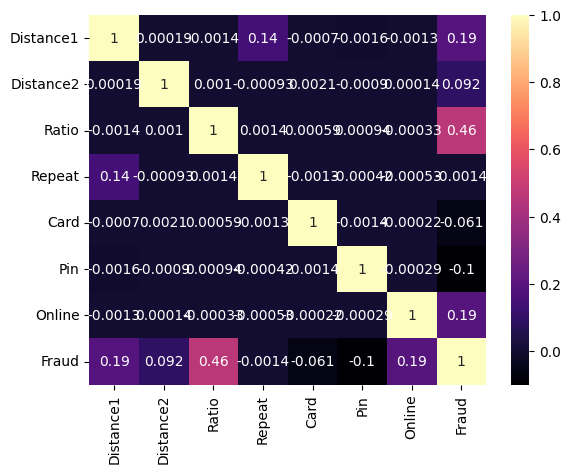

In [ ]:

sns.heatmap(dataset.corr(), annot=True, cmap='magma')

In [ ]:
import pickle

with open("model_pickle.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
import pickle

with open("model_pickle.pkl", "rb") as f:
    model = pickle.load(f)